In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson

df = pd.read_csv(r"Book1.csv",parse_dates=["date"], dayfirst=True)
variables = ["CPIH excluding Energy", "Output growth", "Energy", "Sonia",]
df = df[["date_idx"] + variables].dropna()
df.head()

,date_idx,CPIH excluding Energy,Output growth,Energy,Sonia
0,199701,70.982,61.6,45.027,5.900455
1,199702,71.157,61.9,44.947,5.985000
2,199703,71.332,61.8,44.748,5.965068
3,199704,71.682,62.6,44.542,5.961832
4,199705,71.992,62.1,44.515,6.215380


### VAR(4) Model

We consider a VAR(4) model with the following vector:

$$
Y_t =
\begin{pmatrix}
\text{Energy,  } \
\text{CPIH excl. Energy,  } \
\text{GDP,  } \
\text{SONIA rates,  }
\end{pmatrix}
$$

All variables are expressed in log-differences:

$$
Y_t = \log\left(\frac{X_t}{X_{t-1}}\right)
$$

The model is:

$$
Y_t = A_1 Y_{t-1} + A_2 Y_{t-2} + A_3 Y_{t-3} + A_4 Y_{t-4} + \varepsilon_t
$$



In [11]:
# ── 2. ADF TEST (LEVELS) ──────────────────────────────────────────────────────
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    stat = "✓ stationary" if result[1] < 0.05 else "✗ non-stationary"
    # print(f"  {name:30s}: ADF={result[0]:7.3f}, p={result[1]:.3f}  {stat}")


print("\n=== ADF Tests (levels) ===")
for col in variables:
    adf_test(df[col], col)


=== ADF Tests (levels) ===


In [17]:
# ── 3. FIRST DIFFERENCE + ADF TEST ───────────────────────────────────────────
df_diff =np.log(df[variables]).diff().dropna()
 
print("\n=== ADF Tests (first differences) ===")
for col in variables:
    adf_test(df_diff[col], col)
 
# ── 3b. SECOND DIFFERENCE FOR CPIH (still non-stationary at I(1)) ─────────────
# df_diff2 = df_diff.copy()
# df_diff2["CPIH excluding Energy"] = df["CPIH excluding Energy"].diff().diff().dropna()
# df_diff2 = df_diff2.dropna()
 
# print("\n=== ADF Test — CPIH (second difference) ===")
# adf_test(df_diff2["CPIH excluding Energy"], "CPIH excluding Energy (d2)")


=== ADF Tests (first differences) ===


In [18]:
# ── 4. LAG ORDER SELECTION ────────────────────────────────────────────────────
model = VAR(df_diff)
lag_results = model.select_order(maxlags=12)
print("\n=== Lag Order Selection ===")
print(lag_results.summary())
optimal_lag = lag_results.aic
print(f"Optimal lag (AIC): {optimal_lag}")


=== Lag Order Selection ===
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -31.75      -31.71   1.619e-14      -31.74
1       -32.02     -31.80*   1.236e-14      -31.93
2       -32.20      -31.79   1.036e-14      -32.04
3       -32.25      -31.66   9.898e-15      -32.01
4       -32.24      -31.47   9.950e-15      -31.93
5       -32.23      -31.27   1.010e-14      -31.85
6       -32.44      -31.30   8.160e-15      -31.99
7       -32.39      -31.07   8.571e-15      -31.87
8       -32.35      -30.85   8.927e-15      -31.75
9       -32.33      -30.65   9.166e-15      -31.66
10      -32.28      -30.41   9.654e-15      -31.53
11      -32.26      -30.21   9.830e-15      -31.44
12     -32.97*      -30.74  4.855e-15*     -32.08*
--------------------------------------------------
Optimal lag (AIC): 12


Fit the model to get A1, A2, A3, A4

In [20]:
chosen_lag = 4

fitted = model.fit(chosen_lag)
print("\n=== VAR Model Summary ===")
print(fitted.summary())


=== VAR Model Summary ===
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 15, Apr, 2026
Time:                     22:37:02
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -31.5395
Nobs:                     344.000    HQIC:                  -31.9963
Log likelihood:           3670.92    FPE:                9.39716e-15
AIC:                     -32.2987    Det(Omega_mle):     7.74821e-15
--------------------------------------------------------------------
Results for equation CPIH excluding Energy
                              coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------
const                            0.001885         0.000277            6.805           0.000
L1.CPIH excluding Energy        -0.038290         0.055148       

Forecast differentied data over 5 timesteps : FEB, March, April ...

In [21]:
# Try to forecast next data over h timesteps: 
h = 5
# prediction of log dif for 5 years : 
a = fitted.forecast(df_diff.values[chosen_lag:], h)

df_for = pd.concat([df_diff.reset_index(drop=True), pd.DataFrame(a, columns= df_diff.columns)],ignore_index=True)
df_for
df_for = df_for.rename(columns= {a : a+" diff" for a in df_for.columns},)

print("df_diff", len(df_diff), "differenciation makes it lose one line")
print("df",len(df))

df_for

df_diff 348 differenciation makes it lose one line
df 349


,CPIH excluding Energy diff,Output growth diff,Energy diff,Sonia diff
0,0.002462,0.004858,-0.001778,0.014227
1,0.002456,-0.001617,-0.004437,-0.003336
2,0.004895,0.012862,-0.004614,-0.000543
3,0.004315,-0.008019,-0.000606,0.041649
4,0.001555,0.006421,0.001369,0.001171
...,...,...,...,...
348,0.002581,0.001488,0.003187,-0.017679
349,0.001024,0.002369,0.002256,-0.032932
350,0.002642,0.000639,0.007952,-0.036946
351,0.001159,0.002172,0.002691,-0.030459


In [22]:

#reconstitution of forecasted values 
h = 5
df_reconstite = pd.concat([df.iloc[1:].reset_index(drop = True),
                      df_for],
                     axis = 1
                     )

# for c in variables : 
#     for i in range(len(df_diff),len(df_diff)+h) : 
#         df_reconstite.loc[df_reconstite.index[i],c] = df_reconstite.loc[df_reconstite.index[i-1],c]*np.exp(df_reconstite.loc[df_reconstite.index[i-1],c+ " diff"])
        
for i in range(len(df_diff),len(df_diff)+h) : 
    df_reconstite.loc[df_reconstite.index[i],"date_idx"] = df_reconstite.loc[df_reconstite.index[i-1],"date_idx"] +1
    
df_reconstite
    

,date_idx,CPIH excluding Energy,Output growth,Energy,Sonia,CPIH excluding Energy diff,Output growth diff,Energy diff,Sonia diff
0,199702.0,71.157,61.9,44.947,5.985000,0.002462,0.004858,-0.001778,0.014227
1,199703.0,71.332,61.8,44.748,5.965068,0.002456,-0.001617,-0.004437,-0.003336
2,199704.0,71.682,62.6,44.542,5.961832,0.004895,0.012862,-0.004614,-0.000543
3,199705.0,71.992,62.1,44.515,6.215380,0.004315,-0.008019,-0.000606,0.041649
4,199706.0,72.104,62.5,44.576,6.222662,0.001555,0.006421,0.001369,0.001171
...,...,...,...,...,...,...,...,...,...
348,202602.0,NaN,NaN,NaN,NaN,0.002581,0.001488,0.003187,-0.017679
349,202603.0,NaN,NaN,NaN,NaN,0.001024,0.002369,0.002256,-0.032932
350,202604.0,NaN,NaN,NaN,NaN,0.002642,0.000639,0.007952,-0.036946
351,202605.0,NaN,NaN,NaN,NaN,0.001159,0.002172,0.002691,-0.030459


In [23]:
# ── 2. MONTE CARLO PROPAGATION IN LEVEL-SPACE ─────────────────────────────────
N_SIMULATIONS = 5_000
last_known_levels = df.iloc[-1][variables]   # last observed level for each variable
point_forecast = fitted.forecast(df_diff.values[chosen_lag:], h)

def reconstruct_levels(log_diff_path, last_levels):
    """
    Cumulative sum of log-differences → exponentiate back to levels.
    log_diff_path : np.array of shape (h, n_vars)
    
    last_levels   : pd.Series of shape (n_vars,)
    Returns np.array of shape (h, n_vars) in level space.
    """
    levels = np.zeros_like(log_diff_path)
    prev = last_levels.values
    for t in range(len(log_diff_path)):
        levels[t] = prev * np.exp(log_diff_path[t])
        prev = levels[t]
    return levels


# Retrieve the VAR residual covariance matrix (shape n_vars × n_vars)
sigma = fitted.sigma_u   # unbiased residual covariance

mc_results = np.zeros((N_SIMULATIONS, h, len(df_diff.columns)))

rng = np.random.default_rng(seed=42)
for sim in range(N_SIMULATIONS):
    # Draw h correlated noise vectors from the residual distribution
    noise = rng.multivariate_normal(
        mean=np.zeros(len(df_diff.columns)),
        cov=sigma,
        size=h
    )  # shape (h, n_vars)

    # Add noise to the point forecast (log-diff space)
    noisy_log_diff = point_forecast + noise   # shape (h, n_vars)

    # Propagate back to levels
    mc_results[sim] = reconstruct_levels(noisy_log_diff, last_known_levels)


# ── 3. SUMMARISE MC RESULTS ────────────────────────────────────────────────────
percentiles = [2.5, 5, 16, 50, 84, 95, 97.5]   # matches the alphas above

mc_summary = {}
for i, col in enumerate(df_diff.columns):
    mc_summary[col] = pd.DataFrame(
        np.percentile(mc_results[:, :, i], percentiles, axis=0).T,
        columns=[f"p{p}" for p in percentiles]
    )
    mc_summary[col].index.name = "horizon"

# Quick sanity-check: print summary for the first variable
print(mc_summary[df_diff.columns[0]].round(4))

             p2.5        p5       p16       p50       p84       p95     p97.5
horizon                                                                      
0        137.9824  138.0874  138.3452  138.7454  139.1628  139.4300  139.5691
1        137.7321  137.9405  138.3415  138.8899  139.4499  139.8512  140.0632
2        137.8320  138.0861  138.5548  139.2654  139.9559  140.4278  140.6728
3        137.8709  138.1188  138.6242  139.4498  140.2395  140.7709  141.0462
4        137.9682  138.2198  138.8048  139.7242  140.6235  141.2195  141.5321


In [24]:
# ── 4. OPTIONAL — TIDY COMBINED DATAFRAME ─────────────────────────────────────
def build_forecast_df(col_name, point_series, last_levels):
    """
    Returns a single tidy DataFrame for one variable, combining:
    - point forecast (level)
    - MC percentile bands
    """
    point_levels = reconstruct_levels(
        point_forecast,               # (h, n_vars)
        last_levels
    )[:, list(df_diff.columns).index(col_name)]

    out = mc_summary[col_name].copy()
    out.insert(0, "point_forecast", point_levels)
    return out

forecast_dfs = {col: build_forecast_df(col, point_forecast, last_known_levels)
                for col in df_diff.columns}

# Example display
forecast_dfs[df_diff.columns[0]]


,point_forecast,p2.5,p5,p16,p50,p84,p95,p97.5
horizon,,,,,,,,
0,138.755725,137.982355,138.087442,138.345223,138.745361,139.162760,139.429961,139.569103
1,138.897913,137.732069,137.940495,138.341541,138.889916,139.449906,139.851187,140.063232
2,139.265343,137.832047,138.086058,138.554775,139.265424,139.955893,140.427770,140.672837
3,139.426781,137.870874,138.118754,138.624197,139.449836,140.239464,140.770931,141.046249
4,139.707841,137.968182,138.219764,138.804757,139.724182,140.623468,141.219500,141.532114


In [25]:
# ── RECONSTRUCT df_recon WITH MC CONFIDENCE BANDS ────────────────────────────

confidence_levels = {
    "95": (2.5,  97.5),
    "90": (5.0,  95.0),
    "68": (16.0, 84.0),
}

# ── Historical part (levels, no uncertainty) ──────────────────────────────────
df_hist = df.iloc[1:].reset_index(drop=True).copy()  # align with df_diff

# ── Build forecast rows from MC simulations ───────────────────────────────────
# mc_results shape: (N_SIMULATIONS, h, n_vars)

forecast_rows = {}
for i, col in enumerate(df_diff.columns):
    col_sims = mc_results[:, :, i]  # shape (N_SIMULATIONS, h)

    forecast_rows[col]             = np.mean(col_sims, axis=0)   # (h,)
    for label, (lo, hi) in confidence_levels.items():
        forecast_rows[f"{col}_min_{label}"] = np.percentile(col_sims, lo,  axis=0)
        forecast_rows[f"{col}_max_{label}"] = np.percentile(col_sims, hi,  axis=0)

df_forecast_bands = pd.DataFrame(forecast_rows)  # shape (h, n_cols)

# ── Pad historical rows with NaN for the band columns ─────────────────────────
band_cols = [c for c in df_forecast_bands.columns if c not in df_diff.columns]

for col in band_cols:
    df_hist[col] = np.nan   # no uncertainty on observed data

# For the original columns in history, min/max == the observed value itself
for col in df_diff.columns:
    for label in confidence_levels:
        df_hist[f"{col}_min_{label}"] = df_hist[col]
        df_hist[f"{col}_max_{label}"] = df_hist[col]

# ── Stack history + forecast ───────────────────────────────────────────────────
df_recon = pd.concat(
    [df_hist, df_forecast_bands],
    ignore_index=True
)

# ── Flag which rows are forecasted ────────────────────────────────────────────
df_recon["is_forecast"] = False
df_recon.loc[len(df_hist):, "is_forecast"] = True

for i in range(len(df_diff),len(df_diff)+h) : 
    df_recon.loc[df_recon.index[i],"date_idx"] = df_recon.loc[df_recon.index[i-1],"date_idx"] +1

df_recon["date_idx"] = df_recon.date_idx.apply(lambda x: round(x)*100 +1)
df_recon["date_idx"] = pd.to_datetime(df_recon.date_idx, format= "%Y%m%d")
df_recon

,date_idx,CPIH excluding Energy,Output growth,Energy,Sonia,CPIH excluding Energy_min_95,CPIH excluding Energy_max_95,CPIH excluding Energy_min_90,CPIH excluding Energy_max_90,CPIH excluding Energy_min_68,...,Energy_max_90,Energy_min_68,Energy_max_68,Sonia_min_95,Sonia_max_95,Sonia_min_90,Sonia_max_90,Sonia_min_68,Sonia_max_68,is_forecast
0,1997-02-01,71.157000,61.900000,44.947000,5.985000,71.157000,71.157000,71.157000,71.157000,71.157000,...,44.947000,44.947000,44.947000,5.985000,5.985000,5.985000,5.985000,5.985000,5.985000,False
1,1997-03-01,71.332000,61.800000,44.748000,5.965068,71.332000,71.332000,71.332000,71.332000,71.332000,...,44.748000,44.748000,44.748000,5.965068,5.965068,5.965068,5.965068,5.965068,5.965068,False
2,1997-04-01,71.682000,62.600000,44.542000,5.961832,71.682000,71.682000,71.682000,71.682000,71.682000,...,44.542000,44.542000,44.542000,5.961832,5.961832,5.961832,5.961832,5.961832,5.961832,False
3,1997-05-01,71.992000,62.100000,44.515000,6.215380,71.992000,71.992000,71.992000,71.992000,71.992000,...,44.515000,44.515000,44.515000,6.215380,6.215380,6.215380,6.215380,6.215380,6.215380,False
4,1997-06-01,72.104000,62.500000,44.576000,6.222662,72.104000,72.104000,72.104000,72.104000,72.104000,...,44.576000,44.576000,44.576000,6.222662,6.222662,6.222662,6.222662,6.222662,6.222662,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348,2026-02-01,138.752025,102.740229,153.299053,3.691065,137.982355,139.569103,138.087442,139.429961,138.345223,...,158.572246,150.172782,156.467543,2.809338,4.787467,2.918104,4.592202,3.196065,4.188794,True
349,2026-03-01,138.894880,102.982266,153.648451,3.604267,137.732069,140.063232,137.940495,139.851187,138.341541,...,161.316305,149.214781,158.106281,2.439384,5.134308,2.579982,4.852542,2.910174,4.296007,True
350,2026-04-01,139.262215,103.049809,154.892659,3.514389,137.832047,140.672837,138.086058,140.427770,138.554775,...,164.276411,149.421358,160.365436,2.186703,5.427565,2.327914,4.999824,2.695450,4.334508,True
351,2026-05-01,139.440200,103.282481,155.382408,3.445236,137.870874,141.046249,138.118754,140.770931,138.624197,...,166.276923,149.006245,161.885960,1.944390,5.673400,2.120079,5.237542,2.544257,4.372678,True


VAR MODEL with data from 1997 to Jan 2026 

- Output growth (GDP)

- CPIH inflation excluding Energy

- Energy prices

- Sonia rates (averages over a month) to account for interest rates decisions

We estimate log-growth rates as:

$$
Y_t = \log\left(\frac{X_t}{X_{t-1}}\right)
$$

Forecasts in levels are then recovered using:

$$
X_{t+1} = X_t \cdot \exp(Y_{t+1})
$$


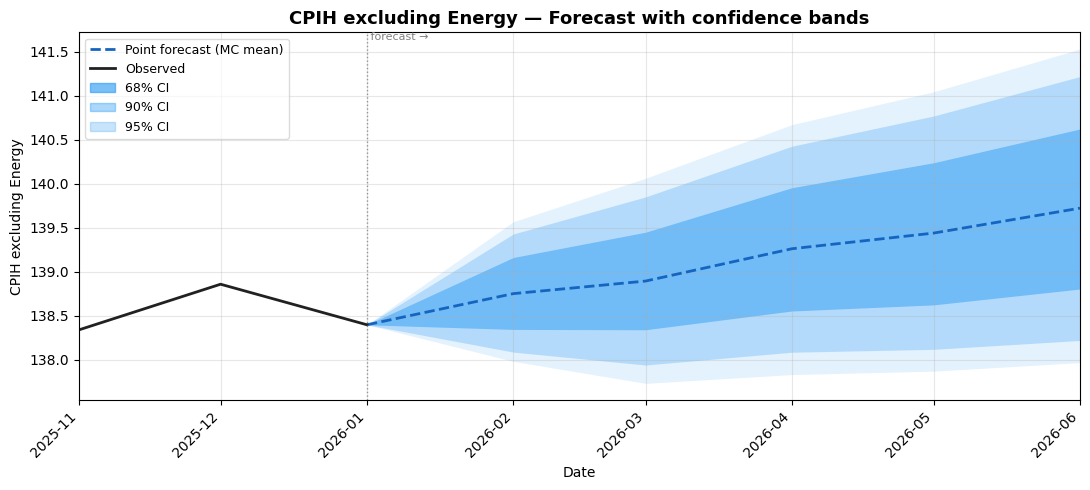

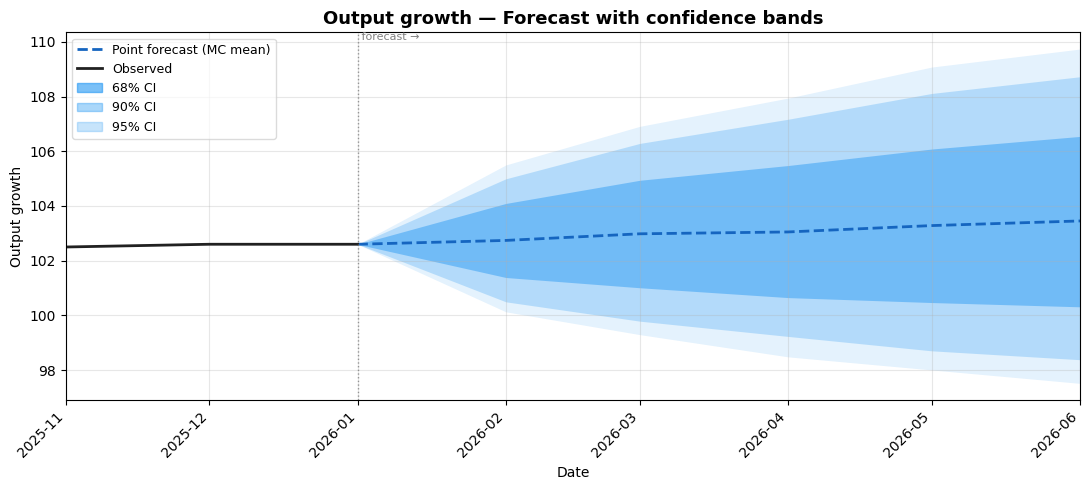

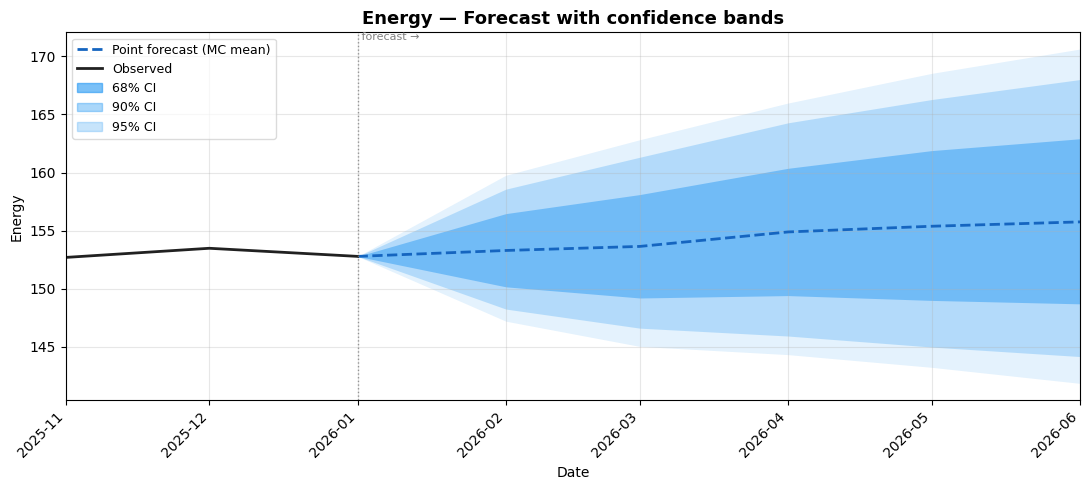

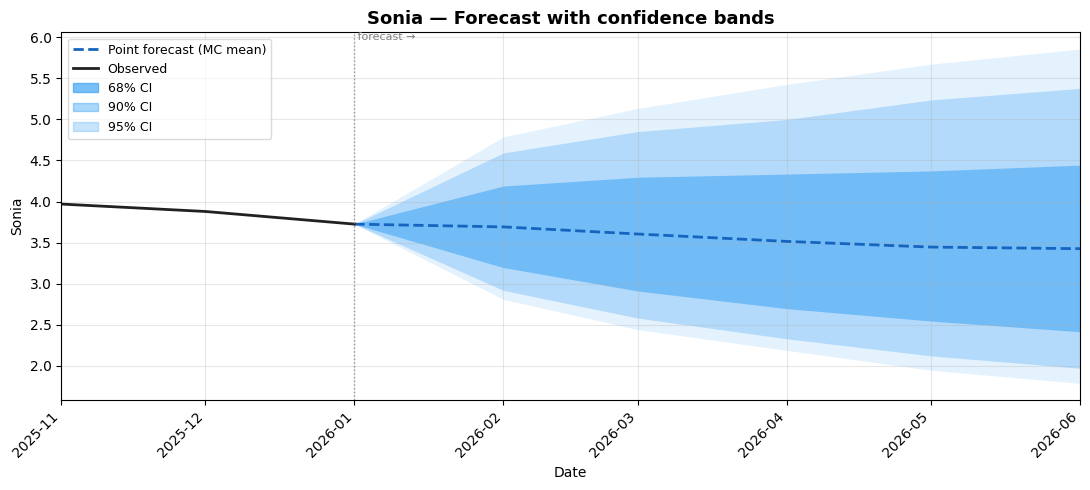

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_forecast_cone(df_recon, col, confidence_levels, n_hist=30):
    """
    Plot historical values + forecast cone with confidence bands for one variable.
    
    Parameters
    ----------
    df_recon          : full reconstructed DataFrame
    col               : variable name to plot (e.g. "GDP")
    confidence_levels : dict {"95": (2.5, 97.5), ...}
    n_hist            : number of historical points to show before the forecast
    """

    df_hist_plot = df_recon[~df_recon["is_forecast"]].tail(n_hist)
    df_fore_plot = df_recon[df_recon["is_forecast"]]

    # Last historical point — used to connect history to forecast smoothly
    last_hist = df_recon[~df_recon["is_forecast"]].iloc[[-1]]

    fig, ax = plt.subplots(figsize=(11, 5))

    # ── Color palette per confidence level ────────────────────────────────────
    band_styles = {
        "68": dict(color="#2196F3", alpha=0.45, label="68% CI"),
        "90": dict(color="#2196F3", alpha=0.25, label="90% CI"),
        "95": dict(color="#2196F3", alpha=0.12, label="95% CI"),
    }

    for label in ["95", "90", "68"]:
        style = band_styles[label]

        stitched = pd.concat([last_hist, df_fore_plot])
        x_band = stitched["date_idx"].values          # ← .values pour sortir du pandas index

        y_lo = np.concatenate([
            last_hist[col].values,
            df_fore_plot[f"{col}_min_{label}"].values
        ])
        y_hi = np.concatenate([
            last_hist[col].values,
            df_fore_plot[f"{col}_max_{label}"].values
        ])

        ax.fill_between(x_band, y_lo, y_hi,
                        color=style["color"], alpha=style["alpha"], linewidth=0)

    # ── Point forecast ────────────────────────────────────────────────────────────
    x_fore = pd.concat([last_hist, df_fore_plot])["date_idx"].values   # ← .values
    y_fore = np.concatenate([last_hist[col].values, df_fore_plot[col].values])

    ax.plot(x_fore, y_fore, color="#1565C0", linewidth=2,
            linestyle="--", label="Point forecast (MC mean)")

    # ── Historical line ───────────────────────────────────────────────────────
    ax.plot(df_hist_plot["date_idx"], df_hist_plot[col],
            color="#212121", linewidth=2, label="Observed")

    # ── Vertical separator history / forecast ─────────────────────────────────
    sep = last_hist["date_idx"].values[0]
    ax.axvline(sep, color="grey", linewidth=1, linestyle=":", alpha=0.8)
    ax.text(sep, ax.get_ylim()[1],
            " forecast →", fontsize=8, color="grey", va="top")

    # ── Legend ────────────────────────────────────────────────────────────────
    band_patches = [
        mpatches.Patch(color="#2196F3", alpha=0.60, label="68% CI"),
        mpatches.Patch(color="#2196F3", alpha=0.38, label="90% CI"),
        mpatches.Patch(color="#2196F3", alpha=0.25, label="95% CI"),
    ]
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + band_patches,
              loc="upper left", fontsize=9, framealpha=0.7)

    # ── X axis formatting ─────────────────────────────────────────────────────
    # Tighten x limits to exactly the visible window (history + forecast)
    x_min = df_hist_plot["date_idx"].iloc[0]
    x_max = df_fore_plot["date_idx"].iloc[-1]
    ax.set_xlim(x_min, x_max)

    fig.autofmt_xdate(rotation=45)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))

    ax.set_title(f"{col} — Forecast with confidence bands", fontsize=13, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


# ── Ensure date_idx is datetime before plotting ───────────────────────────────
df_recon["date_idx"] = pd.to_datetime(df_recon["date_idx"])

# ── Plot all variables ────────────────────────────────────────────────────────
for col in variables:
    plot_forecast_cone(df_recon, col, confidence_levels, n_hist=3)

Energy shock : 

We use this VAR model to estimate : 

- GDP of February 2026

Estimates of March 2026 using : 

- Estimate of Output growth from Feb 2026

- Observed data of the others components

Estimates of April using : 

- Estimates of March + energy shock that acts on inflation + Energy : 

\text{\small Estimates}_{(t = \text{\small April})} = \text{VAR}\!\left(\text{\small Estimates}_{(t = \text{\small March})} + \text{\small Energy shock}\right)

In [39]:
####### data for february : 
chosen_lag = 4
variables = ["CPIH excluding Energy", "Output growth", "Energy", "Sonia",]

feb = np.log(pd.read_csv(r"Book1.csv")[variables]).diff().iloc[-5:]
feb



,CPIH excluding Energy,Output growth,Energy,Sonia
345,0.003255,-0.000977,0.013023,0.000251
346,-0.000853,0.001953,0.002945,0.000272
347,0.003745,0.000975,0.005134,-0.023033
348,-0.003325,0.000000,-0.004551,-0.040480
349,0.004319,NaN,-0.005217,0.000633


In [46]:
# Variance of the 1-step-ahead forecast of february
feb_point = fitted.forecast(df_diff.values[chosen_lag:], 1)        # (1, n_vars)
feb_var   = fitted.forecast_cov(steps=1)[0]  

feb_point
# feb_var/
feb.iloc[-1].values

array([ 0.00431876,         nan, -0.00521677,  0.00063323])

In [58]:
# February: 3 components are observed, only Energy (index e=2) is unknown
e = 1  # index of Energy in y_t
h = 1
# Point forecast of february (all 4 variables)
feb_point = fitted.forecast(df_diff.values[chosen_lag:], 1)[0]  # (4,)

# Replace the 3 known components with their observed values
feb_observed = feb.iloc[-1].values.copy()  # (4,)
feb_observed[1] = feb_point[e]    

print(feb_observed)
# Variance of the 1-step forecast for Energy only
sigma_energy = fitted.forecast_cov(steps=1)[0][e, e]  # scalar
N  = 10000
# Monte Carlo
march_draws = np.zeros((N, h, 4))

for s in range(N):
    feb_draw = feb_observed.copy()
    
    # Only draw Energy from its marginal forecast distribution
    feb_draw[e] = rng.normal(feb_observed[e], np.sqrt(sigma_energy))
    
    history_s = np.vstack([df_diff.values[chosen_lag:], feb_draw])
    march_draws[s] = fitted.forecast(history_s, h)

# Summarise
march_mean = march_draws.mean(axis=0)                              # (h, n_vars)
march_p5   = np.percentile(march_draws, 5,  axis=0)
march_p95  = np.percentile(march_draws, 95, axis=0)
np.vstack([feb[:-1],feb_observed, march_mean])


[ 0.00431876  0.00148784 -0.00521677  0.00063323]


array([[ 0.00325538, -0.00097704,  0.01302343,  0.00025124],
       [-0.00085261,  0.00195313,  0.0029447 ,  0.00027224],
       [ 0.00374461,  0.00097513,  0.00513408, -0.02303292],
       [-0.00332544,  0.        , -0.00455141, -0.04047995],
       [ 0.00431876,  0.00148784, -0.00521677,  0.00063323],
       [ 0.0008822 ,  0.00192909,  0.00155628, -0.03241421]])

Janvier (connu)
    ↓  VAR 1-step + variance sur Energy
Février ~ N(μ_feb, σ²_energy)   ← MC #1 : tirer N février
    ↓  VAR h-steps depuis chaque février tiré
Mars ~ distribution empirique    ← MC #2 : déjà dans la boucle

In [ ]:
march_draws = np.zeros((N, h, n_vars))

for s in range(N):
    # ── MC #1 : draw february ─────────────────────────────────────
    feb_draw = feb_observed.copy()
    feb_draw[e] = rng.normal(feb_observed[e], np.sqrt(sigma_energy))

    # ── MC #2 : draw march noise on top ───────────────────────────
    history_s  = np.vstack([df_diff.values[chosen_lag:], feb_draw])
    point_mar  = fitted.forecast(history_s, h)          # (h, n_vars)
    
    noise      = rng.multivariate_normal(
                     np.zeros(n_vars), Sigma_u, size=h
                 )                                       # (h, n_vars)
    
    march_draws[s] = point_mar + noise                  # propagate both uncertainties

# ── Summary ───────────────────────────────────────────────────────
march_mean = march_draws.mean(axis=0)
march_p5   = np.percentile(march_draws,  5, axis=0)
march_p95  = np.percentile(march_draws, 95, axis=0)

In [ ]:
print("\n=== Durbin-Watson ===")
dw = durbin_watson(fitted.resid)
for col, stat in zip(variables, dw):
    flag = "✓" if 1.5 < stat < 2.5 else "⚠ check"
    print(f"  {col:30s}: {stat:.3f}  {flag}")
    


In [ ]:
march_april_draws = np.zeros((N, h, n_vars))

for s in range(N):
    # ── Tirage de février ─────────────────────────────────────────
    feb_draw = feb_observed.copy()
    feb_draw[e] = rng.normal(feb_observed[e], np.sqrt(sigma_energy))

    # ── Forecast + bruit de mars depuis ce février ────────────────
    history_feb = np.vstack([df_diff.values[chosen_lag:], feb_draw])
    point_mar   = fitted.forecast(history_feb, 1)           # (1, n_vars)
    noise_mar   = rng.multivariate_normal(np.zeros(n_vars), Sigma_u)
    mar_draw    = point_mar[0] + noise_mar                  # (n_vars,)

    # ── Forecast + bruit d'avril depuis février ET mars ───────────
    history_mar = np.vstack([history_feb, mar_draw])
    point_apr   = fitted.forecast(history_mar, 1)           # (1, n_vars)
    noise_apr   = rng.multivariate_normal(np.zeros(n_vars), Sigma_u)
    apr_draw    = point_apr[0] + noise_apr                  # (n_vars,)

    march_april_draws[s, 0] = mar_draw
    march_april_draws[s, 1] = apr_draw

In [ ]:
print("\n=== Granger Causality — does Sonia cause CPIH & Output growth? ===")
gc = fitted.test_causality("CPIH excluding Energy", ["Sonia", "Energy"], kind="f")
print(gc.summary())